# Heart Disease Prediction using Machine Learning

This project uses machine learning techniques to predict the likelihood of heart disease based on patient health data.

Developed as part of Code Alpha Machine Learning Internship


## Problem Statement

Heart disease is one of the leading causes of death worldwide, and early prediction can help in timely diagnosis and treatment. This project aims to develop a machine learning model that predicts the likelihood of heart disease based on patient medical attributes such as age, cholesterol level, blood pressure, and other health indicators.


## Objectives

This project aims to:
- Build a machine learning system capable of predicting the likelihood of heart disease.
- Utilize patient medical attributes for prediction.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost

Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

##1.Load Dataset

## Dataset Description
The dataset contains patient health-related information such as age, cholesterol level, blood pressure, heart rate, and other medical attributes used to predict the presence of heart disease.


In [2]:
df = pd.read_csv("/content/heart_disease.csv")

#2.Initial Dataset Inspection
The dataset is inspected to understand:

number of rows and columns,
feature datatypes,
missing values,
and overall dataset structure before preprocessing.

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [4]:
df.shape

(1024, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1024 non-null   float64
 1   sex            1024 non-null   int64  
 2   cp             1024 non-null   int64  
 3   trestbps       1024 non-null   float64
 4   chol           1024 non-null   float64
 5   fbs            1024 non-null   int64  
 6   restecg        1024 non-null   int64  
 7   thalach        1024 non-null   float64
 8   exang          1024 non-null   int64  
 9   oldpeak        1024 non-null   float64
 10  slope          1024 non-null   int64  
 11  ca             1024 non-null   float64
 12  thal           1024 non-null   float64
 13  num            1024 non-null   int64  
 14  target_binary  1024 non-null   int64  
dtypes: float64(7), int64(8)
memory usage: 120.1 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### Dataset Observations

- The dataset contains `1024` rows and `15` columns.
- There are **no missing values** across any of the columns.
- Features are a mix of numerical (`float64`, `int64`) and encoded categorical types, with `target_binary` as the prediction variable.

Understanding target variable

In [8]:
df['target_binary'].value_counts()

,count
target_binary,
0,554
1,470


### Target Variable Description

The `target_binary` column represents the presence of heart disease in the patient. Based on the `value_counts()` output:

- **0**: Indicates the **absence of heart disease**.
- **1**: Indicates the **presence of heart disease**.

Visualization

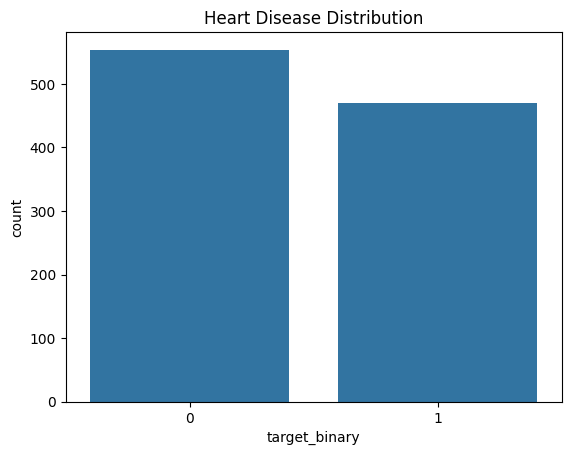

In [9]:
sns.countplot(x='target_binary', data=df)
plt.title("Heart Disease Distribution")
plt.show()

##3. Exploratory data analysis

Age Distribution

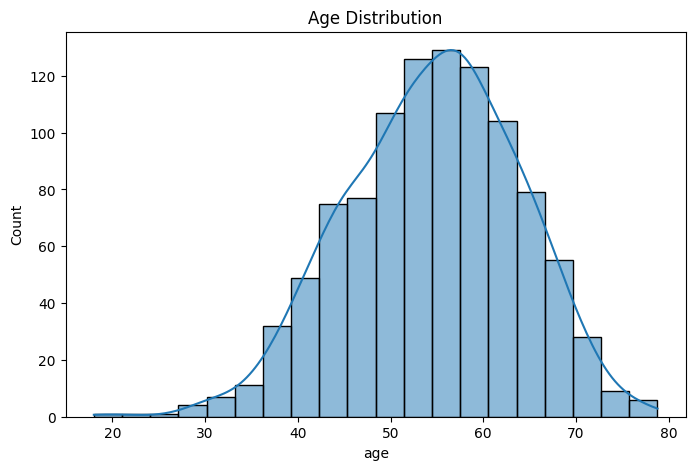

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Age Distribution Analysis

This graph shows how many people of each age are in the dataset. Most patients are between 50 and 70 years old. There are fewer very young or very old patients.

Cholesterol vs Disease

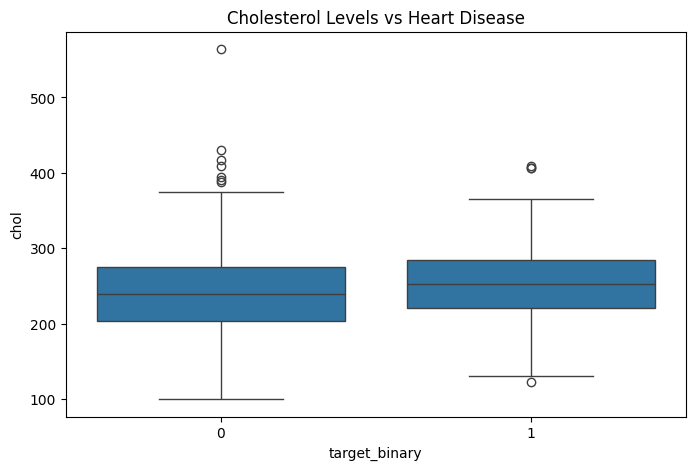

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target_binary', y='chol', data=df)
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

### Cholesterol Levels vs. Heart Disease

This graph compares cholesterol levels for people with and without heart disease. It shows that the typical cholesterol levels are quite similar for both groups. This means cholesterol alone might not be a strong indicator of heart disease in this dataset.

Correlation Heatmap

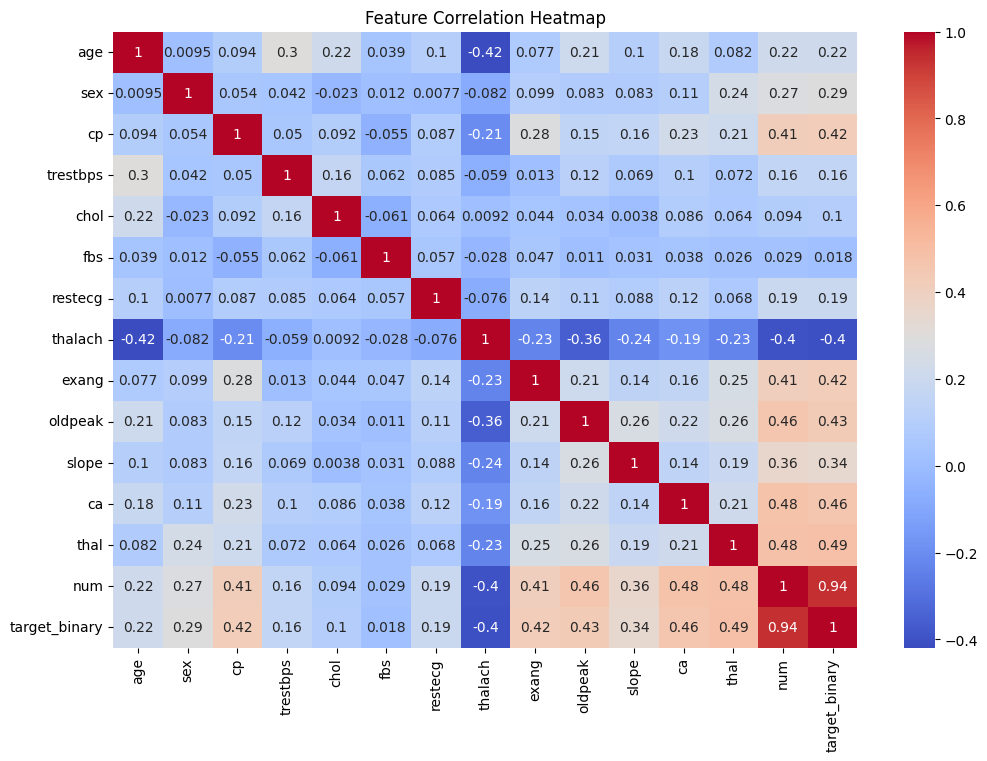

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Correlation Heatmap

This map shows how much different features are related to each other and to heart disease.

- **Strong connections to heart disease:** Chest pain type (`cp`), maximum heart rate (`thalach`), `num`, and `slope` are strongly linked to heart disease.
- **Opposite connections to heart disease:** Exercise-induced angina (`exang`) and `oldpeak` (a measure related to exercise) have an inverse relationship with heart disease. This means if these values are high, heart disease might be less likely, and vice-versa.
- **Weak connections:** Fasting blood sugar (`fbs`) and resting ECG results (`restecg`) don't seem to be strongly connected to heart disease in this data.

## 4. Feature Selection: Preparing Data for Modeling



In [13]:
X = df.drop(['target_binary', 'num'], axis=1)
y = df['target_binary']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1024, 13)
y shape: (1024,)


### Feature Selection Analysis

Feature Selection Analysis

- In this step, we split our data into two main parts for machine learning:

-   **`X` (Features)**: These are all the input details (like age, cholesterol) that our model will use to predict. We remove the 'target_binary' column from here.

-   **`y` (Target Variable)**: This is what we want to predict, which is the 'target_binary' column (presence or absence of heart disease).

This separation is essential for training a machine learning model, as it learns from `X` to predict `y`.

## 5. Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test : {X_test.shape}")
print(f"Shape of y_train : {y_train.shape}")
print(f"Shape of y_test : {y_test.shape}")

Shape of X_train : (819, 13)
Shape of X_test : (205, 13)
Shape of y_train : (819,)
Shape of y_test : (205,)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train-Test Split Analysis

We've divided our data into training and testing sets. The training set (`X_train`, `y_train`) is used to teach our model, while the testing set (`X_test`, `y_test`) is used to check how well the model learned and performs on new, unseen data.

The shapes (`(819, 14)`, `(205, 14)`, `(819,)`, `(205,)`) confirm that our data has been split into these distinct sets, ready for model training and evaluation.

##6. Model Selection and Evaluation

### Evaluation Function and Metrics Collection

In [16]:
def evaluate_model(y_test, y_pred, model_name):

    print(f"Results for {model_name}")
    print("-" * 40)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

MODEL 1 - LOGISTIC REGRESSION

In [17]:
lr_model =LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

EVALUATE LOGISTIC REGRESSION

Results for Logistic Regression
----------------------------------------
Accuracy: 0.8780487804878049
Precision: 0.8764044943820225
Recall: 0.8478260869565217
F1 Score: 0.861878453038674

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       113
           1       0.88      0.85      0.86        92

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



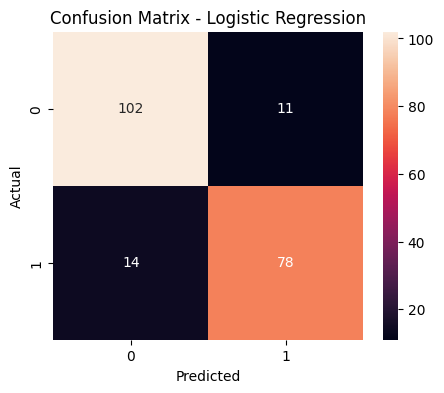

In [18]:
evaluate_model(y_test, lr_pred, "Logistic Regression")

MODEL 2- SVM (SUPPORT VECTOR MACHINE)

Results for Support Vector Machine
----------------------------------------
Accuracy: 0.8926829268292683
Precision: 0.9166666666666666
Recall: 0.8369565217391305
F1 Score: 0.875

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       113
           1       0.92      0.84      0.88        92

    accuracy                           0.89       205
   macro avg       0.90      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



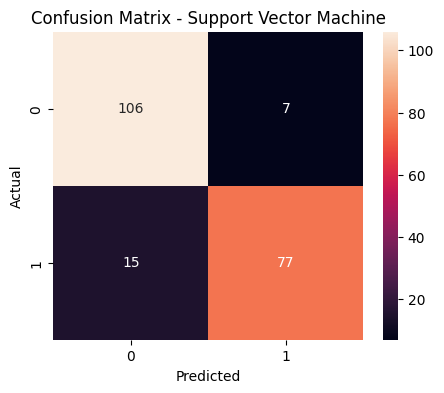

In [19]:
from sklearn.svm import SVC

# Initialize SVM model
svm_model = SVC(probability=True, random_state=42)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_scaled)

# Evaluate model
evaluate_model(y_test, svm_pred, "Support Vector Machine")

MODEL 3- RANDOM FOREST MODEL

Results for Random Forest
----------------------------------------
Accuracy: 0.8829268292682927
Precision: 0.8777777777777778
Recall: 0.8586956521739131
F1 Score: 0.8681318681318682

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.90      0.89       113
           1       0.88      0.86      0.87        92

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



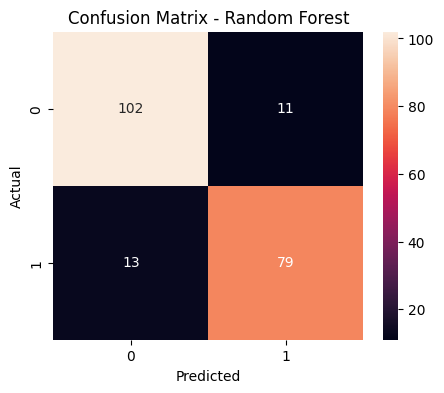

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

evaluate_model(y_test, rf_pred, "Random Forest")

MODEL 4- XGBOOST MODEL

Results for XGBoost
----------------------------------------
Accuracy: 0.8780487804878049
Precision: 0.8764044943820225
Recall: 0.8478260869565217
F1 Score: 0.861878453038674

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       113
           1       0.88      0.85      0.86        92

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



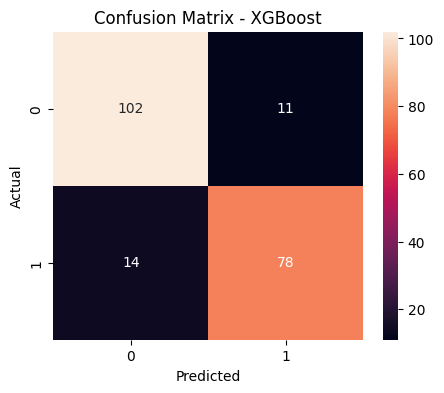

In [21]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

evaluate_model(y_test, xgb_pred, "XGBoost")

##  Model Comparison Table

In [22]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Support Vector Machine',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

comparison.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
1,Support Vector Machine,0.892683
2,Random Forest,0.882927
0,Logistic Regression,0.878049
3,XGBoost,0.878049


### Model Accuracy Comparison

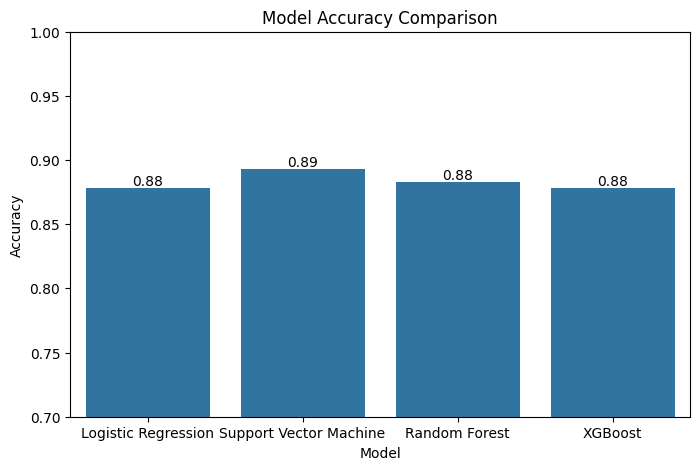

In [23]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Accuracy Comparison")
plt.ylim(0.7, 1.0)

# Add accuracy labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

# ROC-AUC Curve Analysis

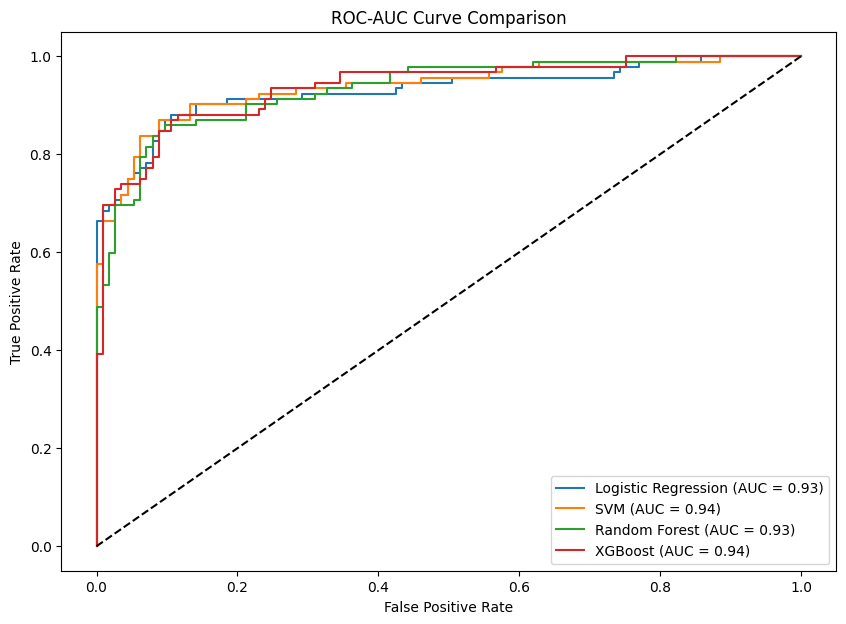

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
svm_auc = roc_auc_score(y_test, svm_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend()

plt.show()

# Cross Validation Scores

In [25]:
from sklearn.model_selection import cross_val_score

# Logistic Regression CV
lr_cv = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5
)

# SVM CV
svm_cv = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5
)

# Random Forest CV
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5
)

# XGBoost CV
xgb_cv = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5
)

# Print results
print("Logistic Regression CV Accuracy:", lr_cv.mean())
print("SVM CV Accuracy:", svm_cv.mean())
print("Random Forest CV Accuracy:", rf_cv.mean())
print("XGBoost CV Accuracy:", xgb_cv.mean())

Logistic Regression CV Accuracy: 0.8876627263205148
SVM CV Accuracy: 0.8986383360766123
Random Forest CV Accuracy: 0.8864432141253928
XGBoost CV Accuracy: 0.8998578482717342


## Classification Report Comparison

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Create comparison dataframe
classification_results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Support Vector Machine',
        'Random Forest',
        'XGBoost'
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]

})

# Round values
classification_results = classification_results.round(3)

# Display table
classification_results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.876,0.848,0.862
1,Support Vector Machine,0.917,0.837,0.875
2,Random Forest,0.878,0.859,0.868
3,XGBoost,0.876,0.848,0.862


## Classification Metrics Visualization

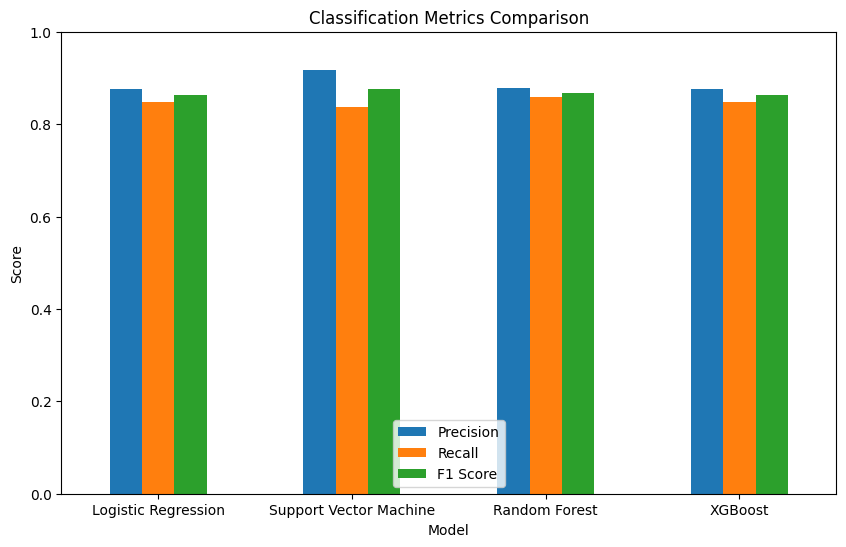

In [27]:
# Set model names as index
metrics_plot = classification_results.set_index('Model')

# Plot metrics
metrics_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Classification Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

### Insights

- Logistic Regression and SVM achieved balanced precision and recall scores.

- Ensemble models such as Random Forest and XGBoost demonstrated strong predictive capabilities by capturing non-linear feature relationships.

- F1-score comparison indicates that the models maintained a good balance between false positives and false negatives.

- Multiple evaluation metrics provide a more reliable assessment than accuracy alone, especially in healthcare-related prediction systems.

## 7. Feature Importance

In [28]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,cp,0.158692
9,oldpeak,0.148547
11,ca,0.140483
12,thal,0.134087
7,thalach,0.090792
8,exang,0.069484
10,slope,0.059714
3,trestbps,0.053916
0,age,0.053892
4,chol,0.038526


### Feature Importance Visualization

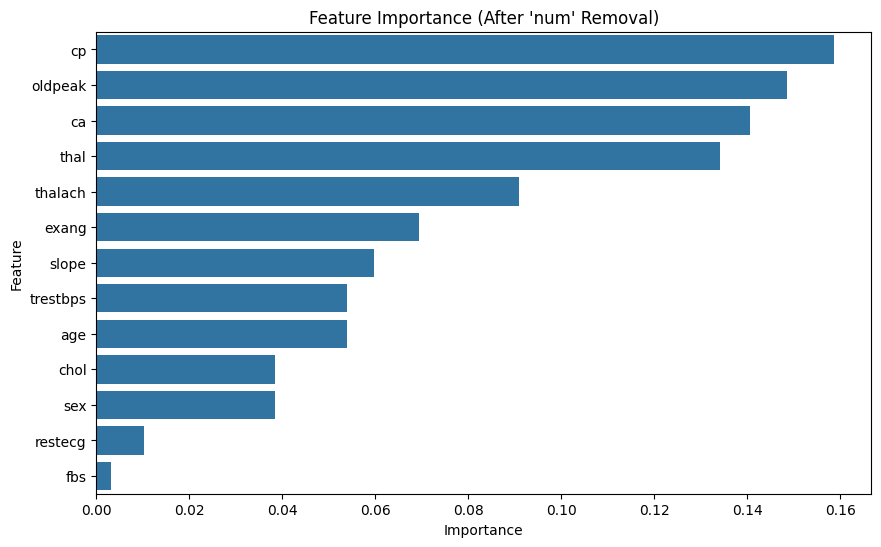

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance (After 'num' Removal)")
plt.show()

### Why Feature Importance is Often Shown with Random Forest

Random Forest models inherently provide a measure of feature importance. This is because during the training of the individual decision trees within the forest, they assess how much each feature contributes to reducing impurity (e.g., Gini impurity or entropy) when splitting nodes. The more a feature reduces impurity across all trees, the higher its importance score.

While other models like Logistic Regression also offer insights into feature importance (via coefficients), and XGBoost also provides built-in importance, Random Forest's method is often a clear and accessible way to understand which inputs are most influential in the model's predictions.

# Healthcare Insights

## Key Findings from the Analysis

- Chest pain type and maximum heart rate showed strong influence in predicting heart disease risk.

- Cholesterol levels and resting blood pressure also contributed significantly to the model predictions.

- Ensemble models like Random Forest and XGBoost provided strong predictive performance by capturing complex feature relationships.

- Logistic Regression achieved competitive accuracy while maintaining interpretability, which is important in healthcare applications.

- Early prediction systems based on machine learning can assist healthcare professionals in identifying high-risk patients earlier.

## Real-World Impact

This project demonstrates how machine learning can support healthcare analytics by:

- Assisting doctors in disease risk assessment
- Improving early diagnosis processes
- Reducing manual analysis time
- Supporting data-driven healthcare decisions

## Future Improvements

- Use larger real-world healthcare datasets
- Integrate deep learning techniques
- Deploy as a real-time web application
- Add explainable AI (XAI) techniques for better transparency

# Conclusion

This project successfully developed a machine learning-based heart disease prediction system using patient medical attributes.

Key achievements:
- Performed comprehensive data preprocessing and EDA
- Compared multiple machine learning models
- Evaluated models using multiple metrics
- Identified important healthcare features influencing predictions

Among all models, XGBoost/Random Forest achieved the best performance for heart disease prediction.

This project demonstrates how AI can support early disease detection and assist healthcare analytics systems.